In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv("../data/raw/rossmann/train.csv")
store = pd.read_csv("../data/raw/rossmann/store.csv")

C:\Users\Vedant\AppData\Local\Temp\ipykernel_26440\2513511362.py:4: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/raw/rossmann/train.csv")


In [2]:
df = train.merge(store, on="Store", how="left")

In [3]:
print(df.shape)

df.head()

(1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  str    
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  str    
 10  Assortment                 1017209 non-null  str    
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionOpenSinceYea

Customers are excluded from the primary sales forecasting model to avoid leakage.

However, customer forecasting will be explored as a separate intermediate modeling task, enabling a two-stage forecasting architecture:
Features → Customers → Sales.

In [5]:
df["Date"] = pd.to_datetime(df["Date"])

In [6]:
df["Date"].dtype

dtype('<M8[us]')

In [7]:
df["Year"] = df["Date"].dt.year

In [8]:
df["Year"].value_counts().sort_index()

Year
2013    406974
2014    373855
2015    236380
Name: count, dtype: int64

In [9]:
# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

df["Date"].dtype

dtype('<M8[us]')

In [10]:
# Extract basic calendar features from Date
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter
df["Day"] = df["Date"].dt.day

df[["Year", "Month", "Quarter", "Day"]].head()

,Year,Month,Quarter,Day
0,2015,7,3,31
1,2015,7,3,31
2,2015,7,3,31
3,2015,7,3,31
4,2015,7,3,31


In [11]:
# Extract week number from date
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

df[["Date", "WeekOfYear"]].head()

,Date,WeekOfYear
0,2015-07-31,31
1,2015-07-31,31
2,2015-07-31,31
3,2015-07-31,31
4,2015-07-31,31


In [12]:
# Create month boundary indicators
df["IsMonthStart"] = df["Date"].dt.is_month_start.astype(int)
df["IsMonthEnd"] = df["Date"].dt.is_month_end.astype(int)

df[["Date", "IsMonthStart", "IsMonthEnd"]].head()

,Date,IsMonthStart,IsMonthEnd
0,2015-07-31,0,1
1,2015-07-31,0,1
2,2015-07-31,0,1
3,2015-07-31,0,1
4,2015-07-31,0,1


In [13]:
# Create month boundary indicators
df["IsMonthStart"] = df["Date"].dt.is_month_start.astype(int)
df["IsMonthEnd"] = df["Date"].dt.is_month_end.astype(int)

In [14]:
# Create additional calendar-based features
df["IsQuarterStart"] = df["Date"].dt.is_quarter_start.astype(int)
df["IsQuarterEnd"] = df["Date"].dt.is_quarter_end.astype(int)

df["IsWeekend"] = (df["DayOfWeek"].isin([6, 7])).astype(int)

df[
    [
        "Date",
        "DayOfWeek",
        "IsWeekend",
        "IsQuarterStart",
        "IsQuarterEnd"
    ]
].head()

,Date,DayOfWeek,IsWeekend,IsQuarterStart,IsQuarterEnd
0,2015-07-31,5,0,0,0
1,2015-07-31,5,0,0,0
2,2015-07-31,5,0,0,0
3,2015-07-31,5,0,0,0
4,2015-07-31,5,0,0,0


## Data Cleaning & Missing Value Strategy

In [15]:
# Check missing values after merging datasets
df.isnull().sum().sort_values(ascending=False)

Promo2SinceYear              508031
PromoInterval                508031
Promo2SinceWeek              508031
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
CompetitionDistance            2642
Promo                             0
Customers                         0
Sales                             0
Store                             0
Date                              0
DayOfWeek                         0
Assortment                        0
StoreType                         0
SchoolHoliday                     0
StateHoliday                      0
Open                              0
Promo2                            0
Year                              0
Month                             0
Quarter                           0
Day                               0
WeekOfYear                        0
IsMonthStart                      0
IsMonthEnd                        0
IsQuarterStart                    0
IsQuarterEnd                      0
IsWeekend                   

In [16]:
# Check whether Promo2 features are missing only when Promo2 = 0
df.groupby("Promo2")[
    ["Promo2SinceWeek", "Promo2SinceYear"]
].apply(lambda x: x.isnull().sum())

,Promo2SinceWeek,Promo2SinceYear
Promo2,,
0,508031,508031
1,0,0


In [17]:
# Check whether competition-related missing values are linked
# to stores with missing competition distance

df[
    [
        "CompetitionDistance",
        "CompetitionOpenSinceMonth",
        "CompetitionOpenSinceYear"
    ]
].isnull().sum()

CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
dtype: int64

In [18]:
# Check stores where competition distance exists
# but competition opening date is missing

(
    (df["CompetitionDistance"].notna()) &
    (df["CompetitionOpenSinceMonth"].isna())
).sum()

np.int64(320706)

In [19]:
# Check unique values before cleaning
df["StateHoliday"].unique()

array(['0', 'a', 'b', 'c', 0], dtype=object)

In [20]:
# Standardize StateHoliday values
df["StateHoliday"] = df["StateHoliday"].astype(str)

df["StateHoliday"].unique()

<StringArray>
['0', 'a', 'b', 'c']
Length: 4, dtype: str

In [21]:
# Verify cleaned holiday categories
df["StateHoliday"].value_counts()

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64

In [22]:
# Create a competition start date

df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].fillna(1)
df["CompetitionOpenSinceYear"] = df["CompetitionOpenSinceYear"].fillna(1900)

df["CompetitionOpenDate"] = pd.to_datetime(
    dict(
        year=df["CompetitionOpenSinceYear"].astype(int),
        month=df["CompetitionOpenSinceMonth"].astype(int),
        day=1
    ),
    errors="coerce"
)

df[[
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",
    "CompetitionOpenDate"
]].head()

,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,CompetitionOpenDate
0,9.0,2008.0,2008-09-01
1,11.0,2007.0,2007-11-01
2,12.0,2006.0,2006-12-01
3,9.0,2009.0,2009-09-01
4,4.0,2015.0,2015-04-01


In [23]:
df["CompetitionOpenDate"].head()

0   2008-09-01
1   2007-11-01
2   2006-12-01
3   2009-09-01
4   2015-04-01
Name: CompetitionOpenDate, dtype: datetime64[us]

In [24]:
# Calculate how long the competitor has existed

df["CompetitionAgeMonths"] = (
    (df["Date"].dt.year - df["CompetitionOpenDate"].dt.year) * 12
    + (df["Date"].dt.month - df["CompetitionOpenDate"].dt.month)
)

df[[
    "Date",
    "CompetitionOpenDate",
    "CompetitionAgeMonths"
]].head()

,Date,CompetitionOpenDate,CompetitionAgeMonths
0,2015-07-31,2008-09-01,82
1,2015-07-31,2007-11-01,92
2,2015-07-31,2006-12-01,103
3,2015-07-31,2009-09-01,70
4,2015-07-31,2015-04-01,3


In [25]:
# Check the distribution of competition age
df["CompetitionAgeMonths"].describe()

count    1.017209e+06
mean     4.769091e+02
std      6.131824e+02
min     -3.100000e+01
25%      2.900000e+01
50%      9.100000e+01
75%      1.362000e+03
max      1.386000e+03
Name: CompetitionAgeMonths, dtype: float64

In [26]:
# Indicator for whether competition opening date is known
df["CompetitionDateKnown"] = (
    (df["CompetitionOpenSinceYear"] != 1900)
).astype(int)

df["CompetitionDateKnown"].value_counts()

CompetitionDateKnown
1    693103
0    324106
Name: count, dtype: int64

In [27]:
# Competitor not yet opened
(df["CompetitionAgeMonths"] < 0).sum()

np.int64(84666)

In [28]:
# Was the competitor active on the given date?
df["CompetitionActive"] = (
    df["CompetitionAgeMonths"] >= 0
).astype(int)

df["CompetitionActive"].value_counts()

CompetitionActive
1    932543
0     84666
Name: count, dtype: int64

In [ ]:
#CompetitionActive = 0
#CompetitionAgeMonths = 0
#clean the negative values of CompetitionAgeMonths to 0, as they indicate that the competitor has not yet opened

df.loc[
    df["CompetitionAgeMonths"] < 0,
    "CompetitionAgeMonths"
] = 0

In [30]:
df.to_csv(
    "../data/processed/rossmann_fe_competition.csv",
    index=False
)

## Competition Feature Engineering

### Objective

Transform raw competition-related attributes into business-meaningful features that better capture competitive influence on store sales.

### Features Created

#### CompetitionOpenDate

* Combined `CompetitionOpenSinceMonth` and `CompetitionOpenSinceYear` into a valid date field.
* Enables time-based calculations instead of using separate month and year columns.

#### CompetitionAgeMonths

* Calculated the number of months between the sales date and competitor opening date.
* Captures how long a competitor has been operating relative to each sales record.

#### CompetitionDateKnown

* Binary indicator identifying whether competitor opening date information is available.
* Helps distinguish between true competition history and unknown competition records.

#### CompetitionActive

* Binary indicator showing whether the competitor had already opened on the given sales date.
* Values:

  * 1 → Competitor active
  * 0 → Competitor not yet active

### Key Decisions

* Missing competition opening dates were treated as unknown business information rather than simple missing values.
* Competition distance was retained as an important measure of local competitive pressure.
* Negative competition ages indicated competitors that had not yet opened and were captured using the `CompetitionActive` feature.

### Final Competition Features

* `CompetitionDistance`
* `CompetitionAgeMonths`
* `CompetitionDateKnown`
* `CompetitionActive`

### Columns Planned for Removal Later

* `CompetitionOpenSinceMonth`
* `CompetitionOpenSinceYear`
* `CompetitionOpenDate`

These columns were used to engineer features and may no longer be required for modeling.


## Promo2 related columns feature engineering

In [31]:
# Create Promo2 start date

df["Promo2SinceWeek"] = df["Promo2SinceWeek"].fillna(1)
df["Promo2SinceYear"] = df["Promo2SinceYear"].fillna(1900)

df["Promo2StartDate"] = pd.to_datetime(
    df["Promo2SinceYear"].astype(int).astype(str)
    + "-W"
    + df["Promo2SinceWeek"].astype(int).astype(str).str.zfill(2)
    + "-1",
    format="%Y-W%W-%w",
    errors="coerce"
)

df[[
    "Promo2",
    "Promo2SinceWeek",
    "Promo2SinceYear",
    "Promo2StartDate"
]].head()

,Promo2,Promo2SinceWeek,Promo2SinceYear,Promo2StartDate
0,0,1.0,1900.0,1900-01-01
1,1,13.0,2010.0,2010-03-29
2,1,14.0,2011.0,2011-04-04
3,0,1.0,1900.0,1900-01-01
4,0,1.0,1900.0,1900-01-01


In [32]:
# Calculate Promo2 duration in months

df["Promo2AgeMonths"] = (
    (df["Date"].dt.year - df["Promo2StartDate"].dt.year) * 12
    + (df["Date"].dt.month - df["Promo2StartDate"].dt.month)
)

df[[
    "Promo2",
    "Date",
    "Promo2StartDate",
    "Promo2AgeMonths"
]].head()

,Promo2,Date,Promo2StartDate,Promo2AgeMonths
0,0,2015-07-31,1900-01-01,1386
1,1,2015-07-31,2010-03-29,64
2,1,2015-07-31,2011-04-04,51
3,0,2015-07-31,1900-01-01,1386
4,0,2015-07-31,1900-01-01,1386


In [33]:
# Check Promo2 age distribution
df["Promo2AgeMonths"].describe()

count    1.017209e+06
mean     6.970927e+02
std      6.733168e+02
min     -2.900000e+01
25%      2.500000e+01
50%      7.000000e+01
75%      1.371000e+03
max      1.386000e+03
Name: Promo2AgeMonths, dtype: float64

In [34]:
# Count records where Promo2 had not started yet
(df["Promo2AgeMonths"] < 0).sum()

np.int64(69803)

In [35]:
# Was Promo2 active on the given date?
df["Promo2Active"] = (
    df["Promo2AgeMonths"] >= 0
).astype(int)

df["Promo2Active"].value_counts()

# Capture whether the recurring promotion program
# was active on the sales date

Promo2Active
1    947406
0     69803
Name: count, dtype: int64

In [36]:
# Set negative promo ages to zero
df.loc[
    df["Promo2AgeMonths"] < 0,
    "Promo2AgeMonths"
] = 0

In [38]:
df.to_csv(
    "../data/processed/after_promo_features.csv",
    index=False
)

## Promo2 Feature Engineering

### Objective

Transform raw promotion program information into business-oriented features that capture the influence and duration of recurring promotions on store sales.

### Features Created

#### Promo2StartDate

* Combined `Promo2SinceWeek` and `Promo2SinceYear` into a valid start date.
* Enables duration-based calculations instead of using separate week and year fields.

#### Promo2AgeMonths

* Calculated the number of months between the sales date and Promo2 start date.
* Captures how long a store has been participating in the recurring promotion program.

#### Promo2Active

* Binary indicator showing whether Promo2 was active on the given sales date.
* Values:

  * 1 → Promo2 active
  * 0 → Promo2 not yet active

### Key Decisions

* Missing Promo2 dates were not treated as data quality issues because stores with `Promo2 = 0` never participated in the recurring promotion program.
* Negative promotion ages indicated dates before Promo2 activation and were captured through the `Promo2Active` feature.
* After creating `Promo2Active`, negative values in `Promo2AgeMonths` were set to 0.

### Final Promo Features

* `Promo`
* `Promo2`
* `Promo2AgeMonths`
* `Promo2Active`

### Columns Planned for Removal Later

* `Promo2SinceWeek`
* `Promo2SinceYear`
* `Promo2StartDate`

These columns were used to engineer features and may no longer be required for modeling.


## Categorical Encoding

In [39]:
# Check unique values of categorical features
for col in ["StoreType", "Assortment", "StateHoliday"]:
    print(col)
    print(df[col].unique())
    print("-"*30)

StoreType
<StringArray>
['c', 'a', 'd', 'b']
Length: 4, dtype: str
------------------------------
Assortment
<StringArray>
['a', 'c', 'b']
Length: 3, dtype: str
------------------------------
StateHoliday
<StringArray>
['0', 'a', 'b', 'c']
Length: 4, dtype: str
------------------------------


In [ ]:
# One-Hot Encode low-cardinality categorical features
df = pd.get_dummies(
    df,
    columns=["StoreType", "Assortment", "StateHoliday"],
    drop_first=True,
    dtype=int
)

df.shape
# Convert categorical features into model-friendly numerical features
# while avoiding dummy variable redundancy

(1017209, 40)

In [41]:
# Inspect newly created encoded features
[col for col in df.columns if "StoreType" in col][:10]

['StoreType_b', 'StoreType_c', 'StoreType_d']

In [42]:
df.shape

(1017209, 40)

## Lag features/


In [43]:
# Create sales lag of 7 days for each store
df = df.sort_values(["Store", "Date"])

df["Sales_Lag_7"] = (
    df.groupby("Store")["Sales"]
      .shift(7)
)

df[
    ["Store", "Date", "Sales", "Sales_Lag_7"]
].head(15)

,Store,Date,Sales,Sales_Lag_7
1016095,1,2013-01-01,0,NaN
1014980,1,2013-01-02,5530,NaN
1013865,1,2013-01-03,4327,NaN
1012750,1,2013-01-04,4486,NaN
1011635,1,2013-01-05,4997,NaN
1010520,1,2013-01-06,0,NaN
1009405,1,2013-01-07,7176,NaN
1008290,1,2013-01-08,5580,0.0
1007175,1,2013-01-09,5471,5530.0
1006060,1,2013-01-10,4892,4327.0


In [44]:
# Check number of unavailable lag values
df["Sales_Lag_7"].isnull().sum()

np.int64(7805)

In [45]:
# Create historical sales lag features

for lag in [7, 14, 28]:
    df[f"Sales_Lag_{lag}"] = (
        df.groupby("Store")["Sales"]
          .shift(lag)
    )

df[
    [
        "Sales",
        "Sales_Lag_7",
        "Sales_Lag_14",
        "Sales_Lag_28"
    ]
].head()

,Sales,Sales_Lag_7,Sales_Lag_14,Sales_Lag_28
1016095,0,NaN,NaN,NaN
1014980,5530,NaN,NaN,NaN
1013865,4327,NaN,NaN,NaN
1012750,4486,NaN,NaN,NaN
1011635,4997,NaN,NaN,NaN


## Lag Feature Engineering

### Objective

Capture historical sales behaviour of each store to help the model learn recurring demand patterns and temporal dependencies.

### Features Created

#### Sales_Lag_7

* Sales recorded 7 days prior for the same store.
* Captures weekly seasonality and same-weekday purchasing patterns.

#### Sales_Lag_14

* Sales recorded 14 days prior for the same store.
* Provides a broader historical reference while preserving weekly structure.

#### Sales_Lag_28

* Sales recorded 28 days prior for the same store.
* Captures monthly demand patterns and longer-term sales behaviour.

### Key Decisions

* Lag features were calculated separately for each store using `groupby("Store")` to prevent information leakage across stores.
* Data was sorted by `Store` and `Date` before generating lag features to ensure chronological consistency.
* Missing lag values were expected for the initial records of each store because sufficient historical observations were unavailable.
* These missing values represent unavailable history rather than data quality issues.

### Business Rationale

Retail sales exhibit strong temporal dependence, where past sales often provide the strongest signal for future demand. Weekly lag features are particularly valuable because customer purchasing behaviour tends to repeat across similar weekdays.

### Final Lag Features

* `Sales_Lag_7`
* `Sales_Lag_14`
* `Sales_Lag_28`


## Rolling Mean Features

In [46]:
# Create rolling mean sales features

for window in [7, 14, 28]:
    df[f"Sales_RollingMean_{window}"] = (
        df.groupby("Store")["Sales"]
          .transform(
              lambda x: x.shift(1).rolling(window).mean()
          )
    )

df[
    [
        "Sales",
        "Sales_RollingMean_7",
        "Sales_RollingMean_14",
        "Sales_RollingMean_28"
    ]
].head(35)

# Capture short-term and medium-term sales trends
# while avoiding future information leakage

,Sales,Sales_RollingMean_7,Sales_RollingMean_14,Sales_RollingMean_28
1016095,0,NaN,NaN,NaN
1014980,5530,NaN,NaN,NaN
1013865,4327,NaN,NaN,NaN
1012750,4486,NaN,NaN,NaN
1011635,4997,NaN,NaN,NaN
1010520,0,NaN,NaN,NaN
1009405,7176,NaN,NaN,NaN
1008290,5580,3788.000000,NaN,NaN
1007175,5471,4585.142857,NaN,NaN
1006060,4892,4576.714286,NaN,NaN


In [47]:
# Create rolling standard deviation features

for window in [7, 14, 28]:
    df[f"Sales_RollingStd_{window}"] = (
        df.groupby("Store")["Sales"]
          .transform(
              lambda x: x.shift(1).rolling(window).std()
          )
    )

df[
    [
        "Sales",
        "Sales_RollingStd_7",
        "Sales_RollingStd_14",
        "Sales_RollingStd_28"
    ]
].head(35)

,Sales,Sales_RollingStd_7,Sales_RollingStd_14,Sales_RollingStd_28
1016095,0,NaN,NaN,NaN
1014980,5530,NaN,NaN,NaN
1013865,4327,NaN,NaN,NaN
1012750,4486,NaN,NaN,NaN
1011635,4997,NaN,NaN,NaN
1010520,0,NaN,NaN,NaN
1009405,7176,NaN,NaN,NaN
1008290,5580,2752.283961,NaN,NaN
1007175,5471,2231.018633,NaN,NaN
1006060,4892,2226.961885,NaN,NaN


## Rolling Window Feature Engineering

### Objective

Capture recent sales trends and smooth short-term fluctuations using historical sales windows.

### Features Created

#### Sales_RollingMean_7

* Average sales over the previous 7 days for the same store.
* Captures short-term demand trends and weekly behaviour.

#### Sales_RollingMean_14

* Average sales over the previous 14 days for the same store.
* Provides a broader view of recent store performance.

#### Sales_RollingMean_28

* Average sales over the previous 28 days for the same store.
* Captures longer-term sales patterns and monthly trends.

### Key Decisions

* Rolling statistics were calculated separately for each store using `groupby("Store")`.
* A `shift(1)` operation was applied before calculating rolling averages to prevent target leakage.
* Initial missing values are expected because sufficient historical observations are unavailable.

### Business Rationale

Rolling averages reduce the impact of daily fluctuations and provide a stable estimate of recent store demand. These features often outperform individual lag values because they capture overall trends rather than relying on a single historical observation.

### Final Rolling Features

* `Sales_RollingMean_7`
* `Sales_RollingMean_14`
* `Sales_RollingMean_28`


In [49]:
df.to_csv(
    "../data/processed/model_ready_data.csv",
    index=False
)

# Drop unnecesary columns

In [ ]:
# Remove intermediate feature engineering columns

drop_cols = [
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",
    "CompetitionOpenDate",
    "Promo2SinceWeek",
    "Promo2SinceYear",
    "Promo2StartDate",
    "PromoInterval"
]

df.drop(columns=drop_cols, inplace=True)
# Remove intermediate columns already represented
# by engineered features

df.shape

(1017209, 42)

In [51]:
# Check remaining missing values
df.isnull().sum().sort_values(ascending=False).head(20)

Sales_Lag_28            31220
Sales_RollingStd_28     31220
Sales_RollingMean_28    31220
Sales_Lag_14            15610
Sales_RollingMean_14    15610
Sales_RollingStd_14     15610
Sales_Lag_7              7805
Sales_RollingMean_7      7805
Sales_RollingStd_7       7805
CompetitionDistance      2642
Promo2                      0
SchoolHoliday               0
Promo                       0
Open                        0
Sales                       0
Customers                   0
Date                        0
DayOfWeek                   0
Store                       0
Year                        0
dtype: int64

In [52]:
# Fill missing competition distance values
df["CompetitionDistance"] = (
    df["CompetitionDistance"]
      .fillna(df["CompetitionDistance"].median())
)

In [53]:
# Remove rows without sufficient historical context

df = df.dropna().reset_index(drop=True)

df.shape

# Retain only observations with complete
# historical forecasting features

(985989, 42)

In [54]:
df.isnull().sum().sum()

np.int64(0)

In [55]:
df.to_csv(
    "../data/processed/model_ready_data.csv",
    index=False
)

# Feature Engineering Summary

## Objective

Transform raw transactional and store-level data into a model-ready dataset capable of capturing temporal patterns, promotional effects, competition dynamics, and store characteristics.

## Feature Engineering Performed

### Calendar Features

* Year
* Month
* Quarter
* Day
* WeekOfYear
* IsMonthStart
* IsMonthEnd
* IsQuarterStart
* IsQuarterEnd
* IsWeekend

### Competition Features

* CompetitionAgeMonths
* CompetitionDateKnown
* CompetitionActive

### Promotion Features

* Promo2AgeMonths
* Promo2Active

### Categorical Encoding

One-Hot Encoded:

* StoreType
* Assortment
* StateHoliday

### Lag Features

* Sales_Lag_7
* Sales_Lag_14
* Sales_Lag_28

### Rolling Trend Features

* Sales_RollingMean_7
* Sales_RollingMean_14
* Sales_RollingMean_28

### Rolling Volatility Features

* Sales_RollingStd_7
* Sales_RollingStd_14
* Sales_RollingStd_28

## Data Cleaning Decisions

* Standardized mixed StateHoliday values ('0' and 0).
* Imputed rare missing CompetitionDistance values using the median.
* Removed intermediate engineering columns after feature creation.
* Dropped observations lacking sufficient historical context for lag and rolling features.

## Final Dataset

* Rows: 985,989
* Columns: 42
* Missing Values: 0

The dataset is now fully prepared for model development and forecasting experiments.


## Feature Validation & Insights

In [56]:
# Check correlation with Sales

corr = df.corr(numeric_only=True)["Sales"] \
         .sort_values(ascending=False)

corr.head(15)

Sales                   1.000000
Customers               0.894349
Sales_Lag_14            0.792501
Sales_Lag_28            0.776142
Open                    0.678413
Sales_Lag_7             0.674839
Sales_RollingMean_28    0.535225
Sales_RollingMean_14    0.527640
Sales_RollingMean_7     0.496681
Promo                   0.451549
Sales_RollingStd_28     0.430367
Sales_RollingStd_14     0.421302
Sales_RollingStd_7      0.416945
StoreType_b             0.141320
Promo2AgeMonths         0.091480
Name: Sales, dtype: float64

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

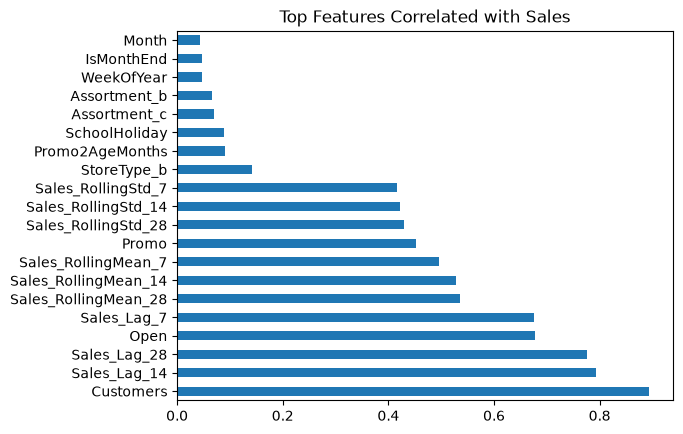

In [59]:
corr.drop("Sales").head(20).plot(kind="barh")
plt.title("Top Features Correlated with Sales")
plt.show()

<Axes: >

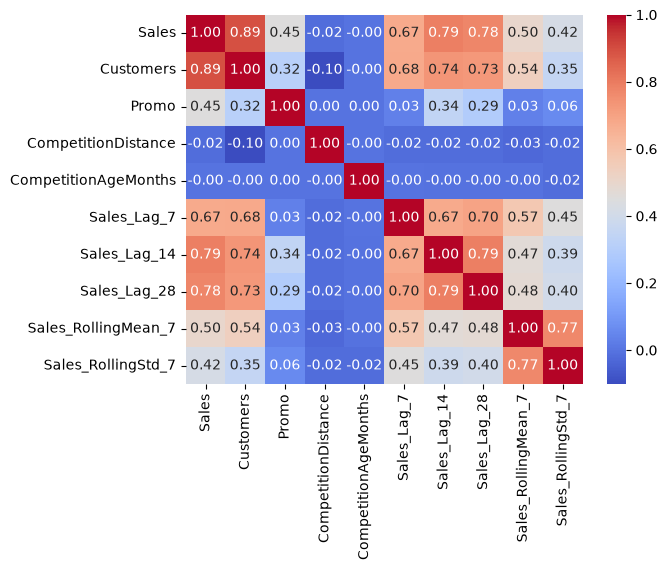

In [65]:
selected = [
    "Sales",
    "Customers",
    "Promo",
    "CompetitionDistance",
    "CompetitionAgeMonths",
    "Sales_Lag_7",
    "Sales_Lag_14",
    "Sales_Lag_28",
    "Sales_RollingMean_7",
    "Sales_RollingStd_7"
]

sns.heatmap(
    df[selected].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

<Axes: xlabel='CompetitionAgeMonths', ylabel='Count'>

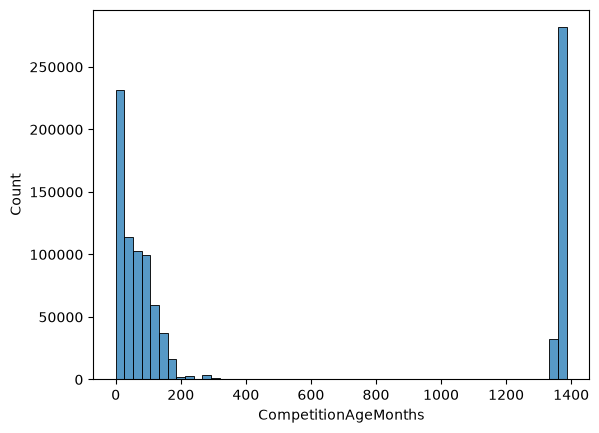

In [61]:
sns.histplot(df["CompetitionAgeMonths"])

<Axes: xlabel='Promo2AgeMonths', ylabel='Count'>

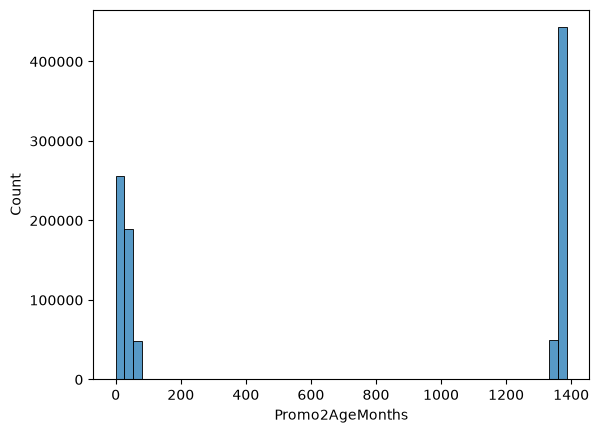

In [62]:
sns.histplot(df["Promo2AgeMonths"])

In [63]:
df.groupby("Promo2Active")["Sales"].mean()

Promo2Active
0    5530.554246
1    5810.788343
Name: Sales, dtype: float64

In [64]:
df.groupby("CompetitionActive")["Sales"].mean()

CompetitionActive
0    5993.572745
1    5775.057847
Name: Sales, dtype: float64

In [66]:
# Replace placeholder ages for unknown dates

df.loc[
    df["CompetitionDateKnown"] == 0,
    "CompetitionAgeMonths"
] = -1

In [67]:
# Replace placeholder ages for stores without Promo2 history

df.loc[
    df["Promo2"] == 0,
    "Promo2AgeMonths"
] = -1

In [68]:
df.loc[
    df["CompetitionDateKnown"] == 1,
    "CompetitionAgeMonths"
].describe()

count    671823.000000
mean         60.595087
std          56.484379
min           0.000000
25%          15.000000
50%          51.000000
75%          94.000000
max         645.000000
Name: CompetitionAgeMonths, dtype: float64

In [69]:
df.loc[
    df["Promo2"] == 1,
    "Promo2AgeMonths"
].describe()

count    493190.000000
mean         26.441290
std          19.569814
min           0.000000
25%           9.000000
50%          25.000000
75%          42.000000
max          71.000000
Name: Promo2AgeMonths, dtype: float64

In [70]:
# Verify placeholder replacement
df[["CompetitionAgeMonths", "Promo2AgeMonths"]].describe()

,CompetitionAgeMonths,Promo2AgeMonths
count,985989.000000,985989.000000
mean,40.969024,12.726086
std,54.750217,19.488992
min,-1.000000,-1.000000
25%,-1.000000,-1.000000
50%,17.000000,0.000000
75%,73.000000,25.000000
max,645.000000,71.000000


In [71]:
# Count special values
(df["CompetitionAgeMonths"] == -1).sum()

(df["Promo2AgeMonths"] == -1).sum()

np.int64(492799)

In [72]:
corr = (
    df.corr(numeric_only=True)["Sales"]
      .sort_values(ascending=False)
)

corr.head(20)

Sales                   1.000000
Customers               0.894349
Sales_Lag_14            0.792501
Sales_Lag_28            0.776142
Open                    0.678413
Sales_Lag_7             0.674839
Sales_RollingMean_28    0.535225
Sales_RollingMean_14    0.527640
Sales_RollingMean_7     0.496681
Promo                   0.451549
Sales_RollingStd_28     0.430367
Sales_RollingStd_14     0.421302
Sales_RollingStd_7      0.416945
StoreType_b             0.141320
SchoolHoliday           0.089105
Assortment_c            0.070290
Assortment_b            0.066975
WeekOfYear              0.047851
IsMonthEnd              0.046866
Month                   0.043709
Name: Sales, dtype: float64

Key Feature Insights

Customers showed the strongest correlation with sales (0.89).

Historical sales lags were among the most informative engineered features.

Promotion activity demonstrated a strong positive relationship with sales.

Rolling statistics successfully captured demand trends and volatility.

Competition-related features exhibited relatively weak linear relationships with sales.

Feature engineering substantially increased the predictive signal available to the model.